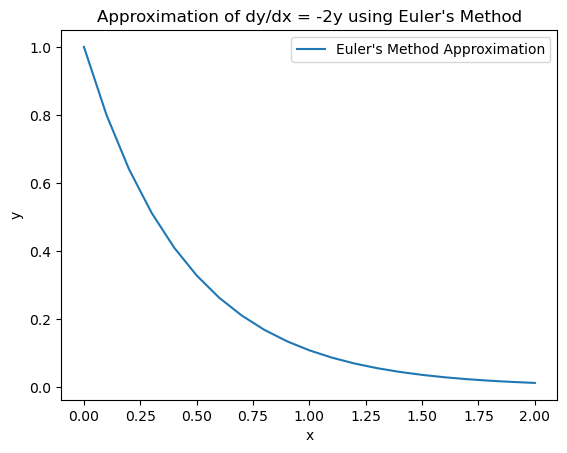

In [2]:
import numpy as np
import matplotlib.pyplot as plt

h = 0.1
x_start, x_end = 0, 2
num_steps = int((x_end - x_start) / h)
x_values = np.linspace(x_start, x_end, num_steps + 1)
y_values = np.zeros(num_steps + 1)

y_values[0] = 1 
def f(x, y):
    return -2 * y

for i in range(num_steps):
    y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

plt.plot(x_values, y_values, label="Euler's Method Approximation")
plt.xlabel('x')
plt.ylabel('y')
plt.title("Approximation of dy/dx = -2y using Euler's Method")
plt.legend()
plt.show()

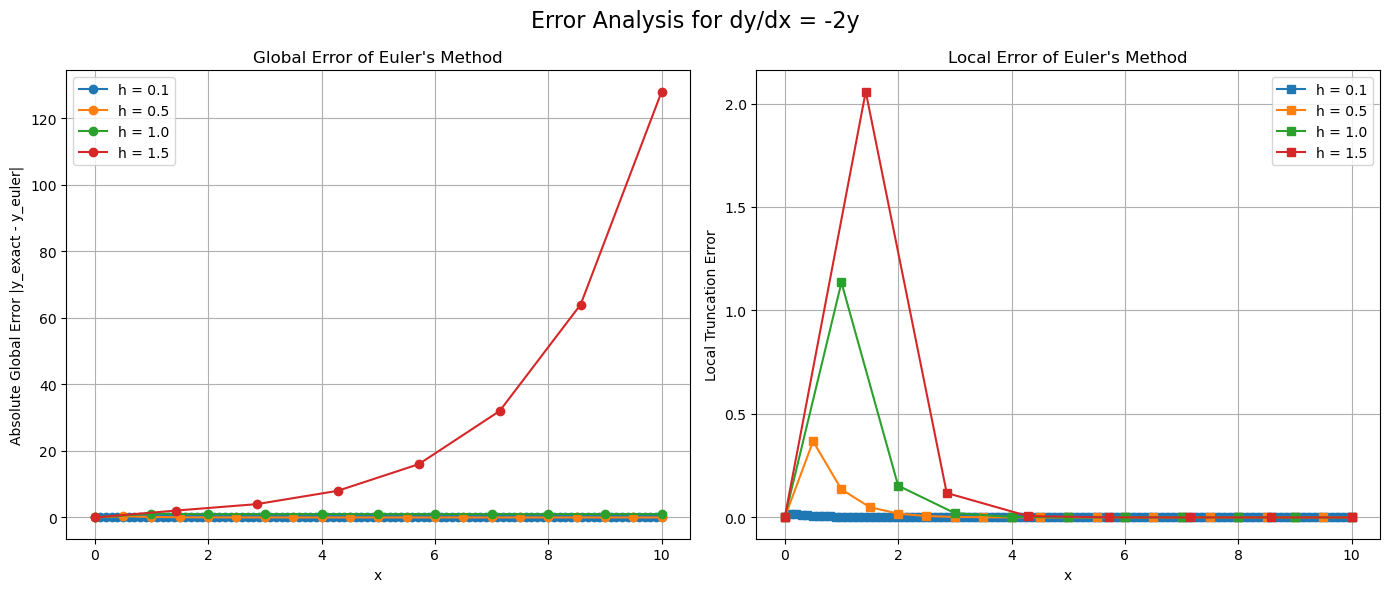

In [3]:
## Ch-16
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    """The differential equation dy/dx = -2y"""
    return -2 * y

def exact_solution(x):
    """The exact analytical solution y(x) = e^(-2x)"""
    return np.exp(-2 * x)

x_start, x_end = 0, 10
step_sizes = [0.1, 0.5, 1.0, 1.5]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for h in step_sizes:
    num_steps = int(np.round((x_end - x_start) / h))
    x_values = np.linspace(x_start, x_end, num_steps + 1)

    y_euler = np.zeros(num_steps + 1)
    y_euler[0] = 1
    local_error = np.zeros(num_steps + 1)

    y_exact = exact_solution(x_values)

    for i in range(num_steps):
        y_euler[i + 1] = y_euler[i] + h * f(x_values[i], y_euler[i])
        local_step_approx = y_exact[i] + h * f(x_values[i], y_exact[i])
        local_error[i + 1] = np.abs(y_exact[i + 1] - local_step_approx)

    global_error = np.abs(y_exact - y_euler)
    
    ax1.plot(x_values, global_error, marker='o', label=f'h = {h}')
    ax2.plot(x_values, local_error, marker='s', label=f'h = {h}')

ax1.set_title("Global Error of Euler's Method")
ax1.set_xlabel("x")
ax1.set_ylabel("Absolute Global Error |y_exact - y_euler|")
ax1.legend()
ax1.grid(True)
ax2.set_title("Local Error of Euler's Method")
ax2.set_xlabel("x")
ax2.set_ylabel("Local Truncation Error")
ax2.legend()
ax2.grid(True)
plt.suptitle("Error Analysis for dy/dx = -2y", fontsize=16)
plt.tight_layout()
plt.show()